WORK IN PROGRESS

The goal is to build up a vizual intuiton as to why dialtion might be beeter core use caes were you want to keep the same level of resolution but want to have a larger receptive field.

In [38]:
import cv2
import numpy as np
import matplotlib.pyplot as plt
import torch
import torchvision.transforms as transforms

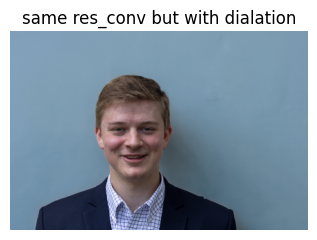

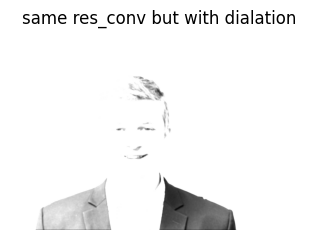

Original size reduced by factor 5
Torch convolution applied with kernel size 3 and dilation 5


In [ ]:
image_path = "/Users/kuba/Documents/photos/headshot_less_one_MB.jpg"
factor = 5 # Reduction factor

def process_image():
    # Load the image
    img = cv2.imread(image_path)
    
    # Convert from BGR to RGB (OpenCV loads images in BGR by default)
    img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)
    
    # # Get original dimensions
    # height, width = img.shape[:2]
    
    # # Reduce resolution by factor
    # new_height, new_width = height // factor, width // factor
    # resized_img = cv2.resize(img, (new_width, new_height))
    
    # # Display the resized image
    # plt.figure(figsize=(10, 5))
    # plt.subplot(1, 2, 1)
    # plt.title(f"lower res Image ({new_width}x{new_height})")
    # plt.imshow(resized_img)
    # plt.axis('off')
    
    # Convert the resized image to PyTorch tensor
    to_tensor = transforms.ToTensor()
    img_tensor = to_tensor(img).unsqueeze(0)  # Add batch dimension

    max_pool = torch.nn.AvgPool2d(kernel_size=3+factor)
    
    # Apply convolution
    res_pool = max_pool(img_tensor)
    
    # Convert back to image
    processed_img = res_pool.squeeze(0).permute(1, 2, 0).detach().numpy()

    # Clip values to valid range
    processed_img = np.clip(processed_img, 0, 1)
    
    # Display the processed image
    plt.subplot(1, 2, 2)
    plt.title("same res_conv but with dialation")
    plt.imshow(processed_img)
    plt.axis('off')
    
    plt.tight_layout()
    plt.show()




    
    # Create a torch convolution layer with dilation
    conv = torch.nn.Conv2d(in_channels=3, out_channels=3, kernel_size=3, dilation=factor, padding=factor)
    
    # # Initialize the weights to all ones and normalize
    # with torch.no_grad():
    #     conv.weight.fill_(1.0 / (3 * 3 * 3))
    #     conv.bias.fill_(0.0)


    with torch.no_grad():
        # Create edge detection kernel (horizontal and vertical edges)
        # This creates the same kernel for all 3 input channels to all 3 output channels
        horizontal_edge = torch.tensor([
            [-1, -2, -1],
            [0, 0, 0],
            [1, 2, 1]
        ], dtype=torch.float32)
        
        vertical_edge = torch.tensor([
            [-1, 0, 1],
            [-2, 0, 2],
            [-1, 0, 1]
        ], dtype=torch.float32)
        
        # Combine horizontal and vertical (magnitude)
        edge_kernel = torch.sqrt(horizontal_edge**2 + vertical_edge**2) / 8.0
        
        # Assign the kernel to each channel
        for i in range(3):  # input channels
            for j in range(3):  # output channels
                conv.weight.data[j, i] = edge_kernel
        
        # Set bias to zero
        conv.bias.fill_(0.0)

    
    # Apply convolution
    res_conv = conv(img_tensor)
    
    # Convert back to image
    processed_img = res_conv.squeeze(0).permute(1, 2, 0).detach().numpy()
    
    # Clip values to valid range
    processed_img = np.clip(processed_img, 0, 1)
    
    # Display the processed image
    plt.subplot(1, 2, 2)
    plt.title("same res_conv but with dialation")
    plt.imshow(processed_img)
    plt.axis('off')
    
    plt.tight_layout()
    plt.show()
    
    return res_conv, processed_img

# Run the function
if __name__ == "__main__":
    resized, processed = process_image()
    print(f"Original size reduced by factor {factor}")
    print(f"Torch convolution applied with kernel size 3 and dilation {factor}")